# Repository as Policy with RHO

CaP-X writes a Python robot policy. RHO treats the repository containing that policy as the object to optimize: an agent edits files, the simulator scores the repository, and HELIX keeps only improvements.

In this notebook we will:

1. Start from an **authentic failed Gemma CaP-X cube-stack policy**.
2. Deploy that exact file on five held-out simulator seeds.
3. Run one bounded HELIX/OpenCode generation with local Gemma E2B.
4. Deploy the evolved repository on the **same five seeds**.
5. Compare completion, reward, failures, source changes, videos, and runtime.

The LLM is used only during evolution. Before and after rollouts execute frozen policy files.

> This is a workshop-sized RHO experiment, not a reproduction of the paper's full training run.

In [1]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Experimental design

A fair before/after comparison needs more than one favorable rollout.

- **Task:** pick up the red cube and stack it on the green cube.
- **Evolution data:** the repository records trial 1 as training and trial 2 as validation.
- **Test data:** five seed/trial IDs are sampled from a separate range and never shown to the evolution agent.
- **Paired comparison:** the same five test seeds are reused after evolution.
- **Frozen deployment:** neither policy file changes during its five rollouts.
- **Failure rule:** a policy that raises an exception receives evaluator reward `0`, even if partial robot motion earned raw simulator reward first.

A fixed meta-seed makes the *selection* of the five test seeds reproducible. MuJoCo, perception, and grasp sampling can still contain nondeterminism, so five trials are a useful smoke test rather than a statistical guarantee.
"""))


## Experimental design

A fair before/after comparison needs more than one favorable rollout.

- **Task:** pick up the red cube and stack it on the green cube.
- **Evolution data:** the repository records trial 1 as training and trial 2 as validation.
- **Test data:** five seed/trial IDs are sampled from a separate range and never shown to the evolution agent.
- **Paired comparison:** the same five test seeds are reused after evolution.
- **Frozen deployment:** neither policy file changes during its five rollouts.
- **Failure rule:** a policy that raises an exception receives evaluator reward `0`, even if partial robot motion earned raw simulator reward first.

A fixed meta-seed makes the *selection* of the five test seeds reproducible. MuJoCo, perception, and grasp sampling can still contain nondeterminism, so five trials are a useful smoke test rather than a statistical guarantee.


In [2]:
import hashlib
import json
import random
import sys
from pathlib import Path
from time import perf_counter

from IPython.display import Markdown, display

sys.path.insert(0, "/ryzers")
import rho_demo
from capx_demo import llama_metrics, metric_delta, show_rollout_grid

NOTEBOOK_ROOT = Path("/ryzers/notebooks")
if not NOTEBOOK_ROOT.exists():
    NOTEBOOK_ROOT = Path.cwd()

EXPERIMENT_ROOT = Path("/tmp/rho_five_seed_notebook")
FIXTURE_CODE = NOTEBOOK_ROOT / "fixtures/capx_gemma_e4b_sam3_cube_stack_trial_01.py"
FIXTURE_METADATA = NOTEBOOK_ROOT / "fixtures/capx_gemma_e4b_sam3_cube_stack_trial_01.json"

EXPERIMENT_META_SEED = 20260822
TEST_SEEDS = random.Random(EXPERIMENT_META_SEED).sample(range(100, 10_000), 5)

GENERATIONS = 1
RHO_TIMEOUT_SECONDS = 480
ROLLOUT_TIMEOUT_SECONDS = 180

print("RHO mutation model:", rho_demo.MODEL)
print("Held-out rollout seeds:", TEST_SEEDS)

RHO mutation model: Gemma-4-E2B-it-GGUF
Held-out rollout seeds: [8740, 1854, 2195, 9455, 2461]


In [3]:
display(Markdown(r"""
## Start the evaluator and prepare the repository

The simulator calls four local services:

- **OWLv2** grounds each object phrase into a bounding box.
- **SAM2** segments the selected box into a pixel mask.
- **Contact-GraspNet** proposes a 6-DoF grasp for the red cube.
- **PyRoKi** solves inverse kinematics for the Franka arm.

OWLv2 and SAM2 are ungated and baked into the course image; live evaluation needs neither a Hugging Face token nor a model download. The seed policy remains an unmodified historical CaP-X artifact, including its legacy filename and provenance metadata.

`prepare_workshop` creates a disposable Git repository around the recorded CaP-X output. The generated program is copied verbatim into `solver/program.py`; evaluator code, provenance, API documentation, and HELIX/OpenCode configuration are protected from mutation.
"""))


## Start the evaluator and prepare the repository

The simulator calls four local services:

- **OWLv2** grounds each object phrase into a bounding box.
- **SAM2** segments the selected box into a pixel mask.
- **Contact-GraspNet** proposes a 6-DoF grasp for the red cube.
- **PyRoKi** solves inverse kinematics for the Franka arm.

OWLv2 and SAM2 are ungated and baked into the course image; live evaluation needs neither a Hugging Face token nor a model download. The seed policy remains an unmodified historical CaP-X artifact, including its legacy filename and provenance metadata.

`prepare_workshop` creates a disposable Git repository around the recorded CaP-X output. The generated program is copied verbatim into `solver/program.py`; evaluator code, provenance, API documentation, and HELIX/OpenCode configuration are protected from mutation.


In [4]:
setup_started = perf_counter()
servers = rho_demo.ensure_services()
SETUP_SECONDS = perf_counter() - setup_started

ROOT = rho_demo.prepare_workshop(
    EXPERIMENT_ROOT / "candidate",
    artifact=FIXTURE_CODE,
    provenance=FIXTURE_METADATA,
    heldout_trial=2,
    generations=GENERATIONS,
)

PROVENANCE = json.loads((ROOT / "provenance.json").read_text())
SEED_PROGRAM = (ROOT / "solver/program.py").read_text()
SEED_SHA256 = hashlib.sha256(SEED_PROGRAM.encode()).hexdigest()

print(f"Setup wall time: {SETUP_SECONDS:.1f}s")
print("Candidate repository:", ROOT)
print("Training/validation trials:", PROVENANCE["training_trial"], PROVENANCE["heldout_trial"])
print("Seed policy SHA-256:", SEED_SHA256)

Loading Gemma-4-E2B-it-GGUF from the image cache...


Lemonade ready in 4.7s


Services ready · LLM 4.7s · robotics 12.3s · details /tmp/capx-services.log
Setup wall time: 17.0s
Candidate repository: /tmp/rho_five_seed_notebook/candidate
Training/validation trials: 1 2
Seed policy SHA-256: 1e832d66a724443636ef68cdc1d70c4357169317a44b2c65b80b42faa52dd17c


In [5]:
print(SEED_PROGRAM)

buggy_lines = [
    line for line in SEED_PROGRAM.splitlines()
    if "green_pose[0][" in line
]
print("\nSuspicious lines:")
for line in buggy_lines:
    print("  ", line)

print("\nAPI contract excerpt:")
print("get_object_pose(...)[0] is already a flat position array with shape (3,).")

# Code block 0
import numpy

# --- 1. Get object poses and extents ---

# Red cube data
red_pose, red_quat, red_extent = get_object_pose("red cube", return_bbox_extent=True)
# Green cube data
green_pose, _, green_extent = get_object_pose("green cube", return_bbox_extent=True)

# --- 2. Sample grasp pose for red cube ---
red_grasp_position, red_grasp_quat = sample_grasp_pose("red cube")

# --- 3. Approach and grasp the red cube ---
print("Approaching and grasping red cube...")
goto_pose(red_grasp_position, red_grasp_quat, z_approach=0.1)
close_gripper()

# --- 4. Lift the red cube to a safe height ---
# Calculate lift position: original position + 0.2m in Z
lift_position = red_grasp_position.copy()
lift_position[2] += 0.2 
print("Lifting red cube to safe height...")
# Use z_approach=0.0 since we are actively moving the lifted object away from the initial grasp point
goto_pose(lift_position, red_grasp_quat, z_approach=0.0)

# --- 5. Calculate the target placement pose on the green cube -

In [6]:
display(Markdown(r"""
## Roll out the policy before evolution

Each call below creates a fresh cube-stack environment, resets it with one test seed, and executes the same `solver/program.py` in a killable child process. No model is queried.

The evaluator reports two rewards:

- `raw_reward`: progress observed by the simulator, even if code later crashes.
- `reward`: the deployability score used by RHO; execution errors are forced to zero.

This distinction prevents a policy from receiving credit for moving the robot partway and then raising an exception.
"""))


## Roll out the policy before evolution

Each call below creates a fresh cube-stack environment, resets it with one test seed, and executes the same `solver/program.py` in a killable child process. No model is queried.

The evaluator reports two rewards:

- `raw_reward`: progress observed by the simulator, even if code later crashes.
- `reward`: the deployability score used by RHO; execution errors are forced to zero.

This distinction prevents a policy from receiving credit for moving the robot partway and then raising an exception.


In [7]:
def compact_result(result):
    keys = (
        "trial",
        "reward",
        "raw_reward",
        "task_completed",
        "timed_out",
        "stderr",
        "traceback",
        "feedback",
        "video",
        "elapsed_seconds",
    )
    return {key: result.get(key) for key in keys}


def rollout(policy_root, seeds, label, *, capture=False):
    results = []
    print(f"{label}: {len(seeds)} frozen-policy rollouts")
    for index, seed in enumerate(seeds, start=1):
        result = compact_result(
            rho_demo.score_candidate(
                policy_root,
                "val",
                trial=seed,
                capture=capture,
                timeout_seconds=ROLLOUT_TIMEOUT_SECONDS,
            )
        )
        results.append(result)
        status = "PASS" if result["task_completed"] else "FAIL"
        print(
            f"  {index}/5 seed={seed}: {status} · "
            f"reward={float(result['reward'] or 0):.4f} · "
            f"{float(result['elapsed_seconds'] or 0):.1f}s"
        )
    return results


def aggregate(results):
    count = len(results)
    completed = sum(bool(item["task_completed"]) for item in results)
    execution_failures = sum(
        bool(item.get("stderr"))
        or bool(item.get("traceback"))
        or bool(item.get("timed_out"))
        for item in results
    )
    return {
        "trials": count,
        "completed": completed,
        "success_rate": completed / count,
        "mean_reward": sum(float(item["reward"] or 0) for item in results) / count,
        "mean_raw_reward": sum(float(item["raw_reward"] or 0) for item in results) / count,
        "mean_rollout_seconds": sum(float(item["elapsed_seconds"] or 0) for item in results) / count,
        "execution_failures": execution_failures,
    }

In [8]:
before_started = perf_counter()
before_results = rollout(ROOT, TEST_SEEDS, "BEFORE EVOLUTION")
BEFORE_SECONDS = perf_counter() - before_started
before_summary = aggregate(before_results)
before_summary

BEFORE EVOLUTION: 5 frozen-policy rollouts


  1/5 seed=8740: FAIL · reward=0.0000 · 21.1s


  2/5 seed=1854: FAIL · reward=0.0000 · 15.3s


  3/5 seed=2195: FAIL · reward=0.0000 · 16.4s


  4/5 seed=9455: FAIL · reward=0.0000 · 15.7s


  5/5 seed=2461: FAIL · reward=0.0000 · 15.5s


{'trials': 5,
 'completed': 0,
 'success_rate': 0.0,
 'mean_reward': 0.0,
 'mean_raw_reward': 0.5727708217276761,
 'mean_rollout_seconds': 16.78831473365426,
 'execution_failures': 5}

### What failed?

The policy successfully perceives and grasps the red cube, so the simulator can report substantial partial reward. It then evaluates `green_pose[0][2]`.

But `green_pose` has shape `(3,)`. `green_pose[0]` is one scalar X coordinate, and indexing that scalar with `[2]` raises `IndexError`. Because the same shape error is independent of object placement, we expect it to reproduce across seeds.

In [9]:
print(before_results[0]["feedback"])

assert (ROOT / "solver/program.py").read_text() == SEED_PROGRAM
assert hashlib.sha256((ROOT / "solver/program.py").read_bytes()).hexdigest() == SEED_SHA256
print("\nPolicy integrity check passed: all five baseline runs used identical bytes.")

Task not completed.

Sandbox stdout:
Running SAM2 segmentation with box: [158.82, 198.95, 197.84, 249.18]
Object position for red cube: [ 0.47335505 -0.08914276 -0.08293656]
Object quaternion wxyz for red cube: [-0.17656424  0.78835719  0.44760509 -0.38336366]
Object extent for red cube: [0.06195792 0.06678181 0.03031685]
Running SAM2 segmentation with box: [292.05, 238.94, 349.4, 312.29]
Object position for green cube: [ 0.56043642  0.06667629 -0.08141803]
Object quaternion wxyz for green cube: [-0.2148124  -0.52066329 -0.07333128 -0.82303578]
Object extent for green cube: [0.07936165 0.06637419 0.0483102 ]
Running SAM2 segmentation with box: [158.82, 198.95, 197.84, 249.18]
Grasp sample position for red cube: [ 0.45980759 -0.08601516 -0.0937141 ]
Grasp sample quaternion wxyz for red cube: [-0.20207883 -0.00099824  0.97645529 -0.07548617]
Approaching and grasping red cube...
Lifting red cube to safe height...


Sandbox stderr:
Traceback (most recent call last):
  File "/ryzers/cap-x/c

## Evolve the repository

`run_helix` starts one bounded generation:

1. HELIX scores the unmodified repository on its training example.
2. OpenCode gives local Gemma E2B read/edit/bash tools in a worktree. It may edit files below `solver/`.
3. The protected evaluator executes the candidate in CaP-X.
4. A child that does not strictly improve is rejected.
5. HELIX exports the best accepted repository as `live_best/`.

The agent can read the API contract and evaluator traceback, but it does **not** receive `TEST_SEEDS` or the five rollout results above.

In [10]:
evolution_metrics_before = llama_metrics()
evolution_started = perf_counter()
live_run = rho_demo.run_helix(
    ROOT,
    generations=GENERATIONS,
    timeout_seconds=RHO_TIMEOUT_SECONDS,
)
EVOLUTION_SECONDS = perf_counter() - evolution_started
EVOLUTION_LLM_METRICS = metric_delta(evolution_metrics_before, llama_metrics())
summary = rho_demo.summarize_run(ROOT)

print(
    f"HELIX: {EVOLUTION_SECONDS:.1f}s wall · "
    f"{EVOLUTION_LLM_METRICS.get('prompt_seconds_total', 0):.1f}s prompt ingest · "
    f"{EVOLUTION_LLM_METRICS.get('tokens_predicted_seconds_total', 0):.1f}s generation"
)
print("Accepted mutation:", summary["accepted"])

if not summary["improved_best"]:
    raise RuntimeError("No improved candidate was produced; inspect the HELIX status and rerun.")

EVOLVED_ROOT = Path(summary["live_best"])
EVOLVED_PROGRAM = (EVOLVED_ROOT / "solver/program.py").read_text()
EVOLVED_SHA256 = hashlib.sha256(EVOLVED_PROGRAM.encode()).hexdigest()

print("\nSemantic mutation:")
for item in summary["semantic_mutation"]:
    print("  -", item)
print("\nAccepted source diff:\n")
print(summary["best_diff"])
print("Evolved policy SHA-256:", EVOLVED_SHA256)

HELIX: 109.5s wall · 5.2s prompt ingest · 25.8s generation
Accepted mutation: True

Semantic mutation:
  - Changed solver/program.py

Accepted source diff:

--- seed/solver/program.py
+++ best/solver/program.py
@@ -27,7 +27,7 @@
 # --- 5. Calculate the target placement pose on the green cube ---
 
 # Green cube center Z coordinate
-green_center_z = green_pose[0][2]
+green_center_z = green_pose[2]
 # Half height of green cube
 green_half_height = green_extent[2] / 2
 # Half height of red cube
@@ -37,7 +37,7 @@
 place_z = green_center_z + green_half_height + red_half_height
 
 # Target position (X, Y matches green cube center, Z is stacking height)
-placement_position = numpy.array([green_pose[0][0], green_pose[0][1], place_z])
+placement_position = numpy.array([green_pose[0], green_pose[1], place_z])
 
 # --- 6. Approach and place the red cube ---
 print("Moving to placement location on green cube...")

Evolved policy SHA-256: 83b711e61a4e30e66ae0f83b1d35a4d568d05eca9b283cf491e20ea71295

## Roll out the evolved policy on the same five seeds

Nothing about the test set changes here: same task, same seed order, same evaluator, and same timeout. The only experimental variable is the repository selected by HELIX.

This paired design lets us separate a real code improvement from an easier second batch of scenes.

In [11]:
after_started = perf_counter()
after_results = rollout(
    EVOLVED_ROOT,
    TEST_SEEDS,
    "AFTER EVOLUTION",
    capture=True,
)
AFTER_SECONDS = perf_counter() - after_started
after_summary = aggregate(after_results)

assert (EVOLVED_ROOT / "solver/program.py").read_text() == EVOLVED_PROGRAM
assert TEST_SEEDS == [item["trial"] for item in before_results]
assert TEST_SEEDS == [item["trial"] for item in after_results]

print("\nBefore:", before_summary)
print("After: ", after_summary)
show_rollout_grid(after_results)
print("\nPaired seed and policy-integrity checks passed.")

AFTER EVOLUTION: 5 frozen-policy rollouts


  1/5 seed=8740: PASS · reward=1.0000 · 15.9s


  2/5 seed=1854: PASS · reward=1.0000 · 16.0s


  3/5 seed=2195: PASS · reward=1.0000 · 16.1s


  4/5 seed=9455: PASS · reward=1.0000 · 15.9s


  5/5 seed=2461: PASS · reward=1.0000 · 16.2s

Before: {'trials': 5, 'completed': 0, 'success_rate': 0.0, 'mean_reward': 0.0, 'mean_raw_reward': 0.5727708217276761, 'mean_rollout_seconds': 16.78831473365426, 'execution_failures': 5}
After:  {'trials': 5, 'completed': 5, 'success_rate': 1.0, 'mean_reward': 1.0, 'mean_raw_reward': 1.0, 'mean_rollout_seconds': 16.030117815406992, 'execution_failures': 0}


5 rollout videos · 0.2 MB embedded

Paired seed and policy-integrity checks passed.


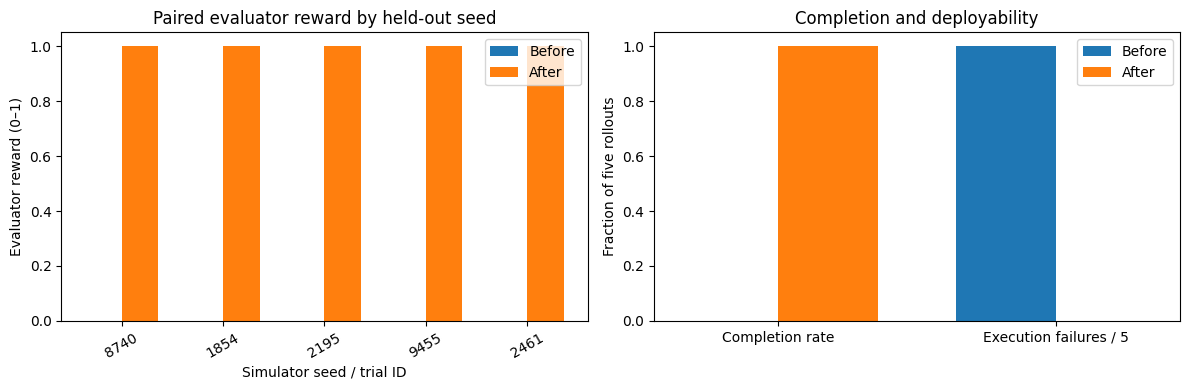

Saved report: /tmp/rho_five_seed_notebook/five_seed_report.json


In [12]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(TEST_SEEDS))
width = 0.36
before_rewards = [float(item["reward"] or 0) for item in before_results]
after_rewards = [float(item["reward"] or 0) for item in after_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x - width / 2, before_rewards, width, label="Before")
axes[0].bar(x + width / 2, after_rewards, width, label="After")
axes[0].set_title("Paired evaluator reward by held-out seed")
axes[0].set_xlabel("Simulator seed / trial ID")
axes[0].set_ylabel("Evaluator reward (0–1)")
axes[0].set_xticks(x, [str(seed) for seed in TEST_SEEDS], rotation=30)
axes[0].set_ylim(0, 1.05)
axes[0].legend()

summary_labels = ["Completion rate", "Execution failures / 5"]
axes[1].bar(
    np.arange(2) - width / 2,
    [before_summary["success_rate"], before_summary["execution_failures"] / 5],
    width,
    label="Before",
)
axes[1].bar(
    np.arange(2) + width / 2,
    [after_summary["success_rate"], after_summary["execution_failures"] / 5],
    width,
    label="After",
)
axes[1].set_title("Completion and deployability")
axes[1].set_ylabel("Fraction of five rollouts")
axes[1].set_xticks(np.arange(2), summary_labels)
axes[1].set_ylim(0, 1.05)
axes[1].legend()
fig.tight_layout()
plt.show()

REPORT_PATH = EXPERIMENT_ROOT / "five_seed_report.json"
report = {
    "schema_version": "rho-notebook-five-seed/v1",
    "task": "cube_stack",
    "experiment_meta_seed": EXPERIMENT_META_SEED,
    "test_seeds": TEST_SEEDS,
    "test_seeds_used_by_evolution": False,
    "seed_policy_sha256": SEED_SHA256,
    "evolved_policy_sha256": EVOLVED_SHA256,
    "before": {"aggregate": before_summary, "results": before_results},
    "evolution": {
        "model": rho_demo.MODEL,
        "generations": GENERATIONS,
        "elapsed_seconds": live_run.elapsed_seconds,
        "llm_metrics": EVOLUTION_LLM_METRICS,
        "accepted": summary["accepted"],
        "improved_best": summary["improved_best"],
        "diff": summary["best_diff"],
    },
    "after": {"aggregate": after_summary, "results": after_results},
    "timing": {
        "setup_seconds": SETUP_SECONDS,
        "service_setup": rho_demo.LAST_SERVICE_TIMING,
        "before_rollouts_seconds": BEFORE_SECONDS,
        "evolution_seconds": EVOLUTION_SECONDS,
        "after_rollouts_seconds": AFTER_SECONDS,
    },
}
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(json.dumps(report, indent=2) + "\n")
print("Saved report:", REPORT_PATH)

In [13]:
service_timing = rho_demo.LAST_SERVICE_TIMING
print("Timing breakdown")
print(f"  LLM/model setup: {service_timing.get('lemonade_seconds', 0):6.1f}s")
print(f"  perception/control setup: {service_timing.get('robotics_seconds', 0):6.1f}s")
print(f"  five baseline rollouts: {BEFORE_SECONDS:6.1f}s")
print(f"  HELIX evolution: {EVOLUTION_SECONDS:6.1f}s")
print(f"    prompt processing: {EVOLUTION_LLM_METRICS.get('prompt_seconds_total', 0):6.1f}s")
print(f"    token generation: {EVOLUTION_LLM_METRICS.get('tokens_predicted_seconds_total', 0):6.1f}s")
print(f"  five video rollouts: {AFTER_SECONDS:6.1f}s")

Timing breakdown
  LLM/model setup:    4.7s
  perception/control setup:   12.3s
  five baseline rollouts:   83.9s
  HELIX evolution:  109.5s
    prompt processing:    5.2s
    token generation:   25.8s
  five video rollouts:   80.2s


In [14]:
before_completed = before_summary["completed"]
after_completed = after_summary["completed"]
crashes_removed = (
    before_summary["execution_failures"] - after_summary["execution_failures"]
)

display(Markdown(f"""
## Interpretation

- **Task completion:** `{before_completed}/5` before → `{after_completed}/5` after.
- **Execution failures:** `{before_summary['execution_failures']}/5` before → `{after_summary['execution_failures']}/5` after.
- **Mean evaluator reward:** `{before_summary['mean_reward']:.3f}` before → `{after_summary['mean_reward']:.3f}` after.
- **Runtime failures removed:** `{crashes_removed}` across the paired rollouts.

The accepted edit generalizes if it removes the shape/indexing crash on seeds that evolution never saw. Task completion can still be below 5/5 because grasp selection, perception, and placement are separate failure modes. RHO repaired the observed program defect; it did not prove that every part of the manipulation strategy is universally robust.

With only five rollouts, report the observed rate rather than treating it as a precise success probability.
"""))


## Interpretation

- **Task completion:** `0/5` before → `5/5` after.
- **Execution failures:** `5/5` before → `0/5` after.
- **Mean evaluator reward:** `0.000` before → `1.000` after.
- **Runtime failures removed:** `5` across the paired rollouts.

The accepted edit generalizes if it removes the shape/indexing crash on seeds that evolution never saw. Task completion can still be below 5/5 because grasp selection, perception, and placement are separate failure modes. RHO repaired the observed program defect; it did not prove that every part of the manipulation strategy is universally robust.

With only five rollouts, report the observed rate rather than treating it as a precise success probability.


## What this notebook demonstrates

RHO did not update model weights and it did not generate a fresh policy for each test scene. It evolved a versioned software artifact once, then deployed the resulting Python file repeatedly.

That separation is the core repository-as-policy idea:

**generate code → evaluate repository → mutate repository → gate on execution → deploy frozen best repository**

The disposable repository, HELIX worktrees, full evaluator feedback, accepted diff, and five-seed report remain under `/tmp/rho_five_seed_notebook/` for inspection. Call `rho_demo.stop_owned_services()` when you are finished and want to release the perception-service processes.

## What to expect

The baseline should fail on all five seeds at the same scalar-index operation. A successful evolution removes that execution failure with direct flat-vector indexing (`green_pose[2]`, `green_pose[0]`, `green_pose[1]`).

Physical completion may remain below 5/5: perception, grasp selection, and placement still vary by scene. The videos and paired metrics make that distinction visible instead of hiding it behind one favorable rollout.